# Figure 3

## Timestamps

Heatmap: Last generated 3/25/2026
Scatterplot: Last generated 43/2026

## Code to calculate the RBP Activity Metric and generate heatmap figure

### Load packages and read in table

In [1]:
import polars as pl
_=pl.Config.set_tbl_cols(100000)
_=pl.Config.set_tbl_rows(10000)
_=pl.Config.set_tbl_width_chars(10000)
_=pl.Config.set_fmt_str_lengths(10000)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm
import seaborn as sns
import pickle
from sklearn.metrics import matthews_corrcoef
from pathlib import Path

In [2]:
# Function to get path for big table

def get_path(cell_line: str, path_file: str = "/project/PlatigLab/users/reece/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/07_reece_biological_validations/data_path.txt") -> str:
    """
    Reads a base directory path from a text file and returns the full path
    to the cell line data directory.

    Args:
        cell_line (str): The name of the cell line (e.g. "K562" or "HepG2").
        path_file (str): Path to the text file containing the base directory path.

    Returns:
        str: Full path to the data file for the given cell line.
    """
    # Read base path from file
    base_path = Path(path_file).read_text().strip()
    
    # Build full path
    full_path = Path(base_path) / f"{cell_line}_all-data.feather"
    
    return str(full_path)

In [3]:
# Read in data for both cell lines

data_path_HepG2 = get_path("HepG2")
all_model_data_HepG2 = pl.read_ipc(data_path_HepG2)

Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


In [4]:
data_path_K562 = get_path("K562")
all_model_data_K562 = pl.read_ipc(data_path_K562)

Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


### Function to generate heatmap data

In [5]:
def rbp_activity_heatmap_data(cell_line, data):
    
    print(cell_line)
    
    # Filter massive dataframe for KD samples, FDR <= 0.1, abs[DeltaPSI] > 0

    filtered_data = (
        data
        .filter(
            (data["Sample Name"].str.contains("KD", literal=True))
            & (data["FDR"] <= 0.1)
            & (data["DeltaPSI"].abs() > 0)
        )    
    )

    # Columns 
    columns_to_keep = [
        "RBP_KD_Target",
        "Sample Name",
        "FDR",
        "DeltaPSI",
        "has_RBP_KD_1",
        "has_RBP_KD_2",
        "has_RBP_KD_3",
        "has_RBP_KD_4",
        "has_RBP_KD_5",
        "has_RBP_KD_6",
        "Raw P-Val",
        "rMATS Event ID"
    ]
    
    rbp_targets = (
        filtered_data["RBP_KD_Target"]
        .unique()
        .sort()
        .to_list()
    )
    
    positions = [1,2,3,4,5,6]

    results = []  # collect all results here

    for rbp in rbp_targets:
        for pos in positions:

            rbp_specific_data = (
            filtered_data
            .filter(
                (pl.col("RBP_KD_Target") == rbp) & (pl.col(f"has_RBP_KD_{pos}") == True))
            .unique(subset=["rMATS Event ID"])) # gets in-silico KD rows per RBP per position

            # Drop unneccesary columns
            rbp_specific_data = rbp_specific_data.select(columns_to_keep)

            # Convert to pandas
            df = rbp_specific_data.to_pandas()

            # Prevents error for no data (SAFB or IGF..1)
            data = df["DeltaPSI"]

            if data.empty:
                continue 

            # DPSI conversion
            df["DeltaPSI"] = df["DeltaPSI"] * -1

            # Calculate the number of positive dPSI and the number of negative dPSI

            num_pos = (df["DeltaPSI"] > 0).sum()
            num_neg = (df["DeltaPSI"] < 0).sum()

            # Do not include rows plots with less than 10 sig. points 

            if (num_pos + num_neg) < 10:
                continue 

            # Normalized Difference Score
            norm_diff = (num_pos - num_neg) / (num_pos + num_neg)

            # Append results
            results.append({
                "RBP": rbp,
                "position": pos,
                "num_pos": num_pos,
                "num_neg": num_neg,
                "norm_diff": norm_diff
            })

    # Final results dataframe
    results_df = pd.DataFrame(results)
    
    df = pd.DataFrame(results_df)

    # Pivot the dataframe to have positions as columns, RBPs as rows, and score as values
    heatmap_data = df.pivot(index='RBP', columns='position', values='norm_diff')

    return heatmap_data

In [6]:
# Get heatmap data and format for plot

HepG2_heatmap = rbp_activity_heatmap_data('HepG2', all_model_data_HepG2)
K562_heatmap = rbp_activity_heatmap_data('K562', all_model_data_K562)

HepG2_heatmap.columns.name = None
K562_heatmap.columns.name = None

# Add Cell Line column
K562_heatmap["Cell Line"] = "K562"
HepG2_heatmap["Cell Line"] = "HepG2"

final_heatmap = pd.concat([K562_heatmap, HepG2_heatmap])

HepG2
K562


In [7]:
final_heatmap.to_csv("heatmap.csv")

### Code to plot heatmap

In [9]:
def plot_rbp_activity_heatmap_test(heatmap_data):

    plt.style.use("/project/PlatigLab/users/reece/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/07_reece_biological_validations/paper.mplstyle")

    # Split data
    k562_data = heatmap_data[heatmap_data["Cell Line"] == "K562"].drop(columns="Cell Line")
    hepg2_data = heatmap_data[heatmap_data["Cell Line"] == "HepG2"].drop(columns="Cell Line")

    # Get union of RBPs across both cell lines
    all_rbps = sorted(set(k562_data.index).union(set(hepg2_data.index)))
    
    # Reindex both datasets to the full RBP list
    k562_data = k562_data.reindex(all_rbps)
    hepg2_data = hepg2_data.reindex(all_rbps)

    # Ensure identical RBP order
    hepg2_data = hepg2_data.reindex(k562_data.index)

    cell_line_data = [("HepG2", hepg2_data), ("K562", k562_data)]

    top_n = len(k562_data)

    vmin = min(df.min().min() for _, df in cell_line_data)
    vmax = max(df.max().max() for _, df in cell_line_data)

    fig, axes = plt.subplots(
        1, 2,
        figsize=(6.5, 0.15 * top_n),  # smaller row height
        dpi=300,
        sharex=True,
        sharey=True
    )

    cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.6])

    for idx, (cell_line, heatmap) in enumerate(cell_line_data):

        sns.heatmap(
            heatmap,
            ax=axes[idx],
            cmap="bwr",
            center=0,
            vmin=vmin,
            vmax=vmax,
            cbar=(idx == 0),
            cbar_ax=(cbar_ax if idx == 0 else None),
            linewidths=0.4,
            linecolor="black"
        )

        axes[idx].set_title(cell_line, fontsize=12, pad=5)
        axes[idx].set_xlabel("")
        axes[idx].set_ylabel("")
        axes[idx].set_facecolor("lightgray")

    # Set RBP labels
    axes[0].set_yticks(np.arange(len(all_rbps)) + 0.5)
    axes[0].set_yticklabels(all_rbps, fontsize=7, rotation=0)

    axes[1].tick_params(axis='y', left=True, labelleft=False)

    axes[0].tick_params(axis='x', labelsize=12)
    axes[1].tick_params(axis='x', labelsize=12)

    label = r'Activity'

    cbar_ax.set_title(label, fontsize=10, pad=10)
    cbar_ax.tick_params(labelsize=10)

    fig.supylabel("RBP", fontsize=14, x=0.09, y=0.52, fontweight="bold")
    fig.supxlabel("Position", fontsize=14, x=0.56, y=-0.03,  fontweight="bold")

    plt.subplots_adjust(left=0.22, right=0.88, top=0.95, bottom=0.08, wspace=0.05)

    plt.show()

    plt.savefig(
        "tmp.pdf", 
        dpi=1000
    )

    return axes

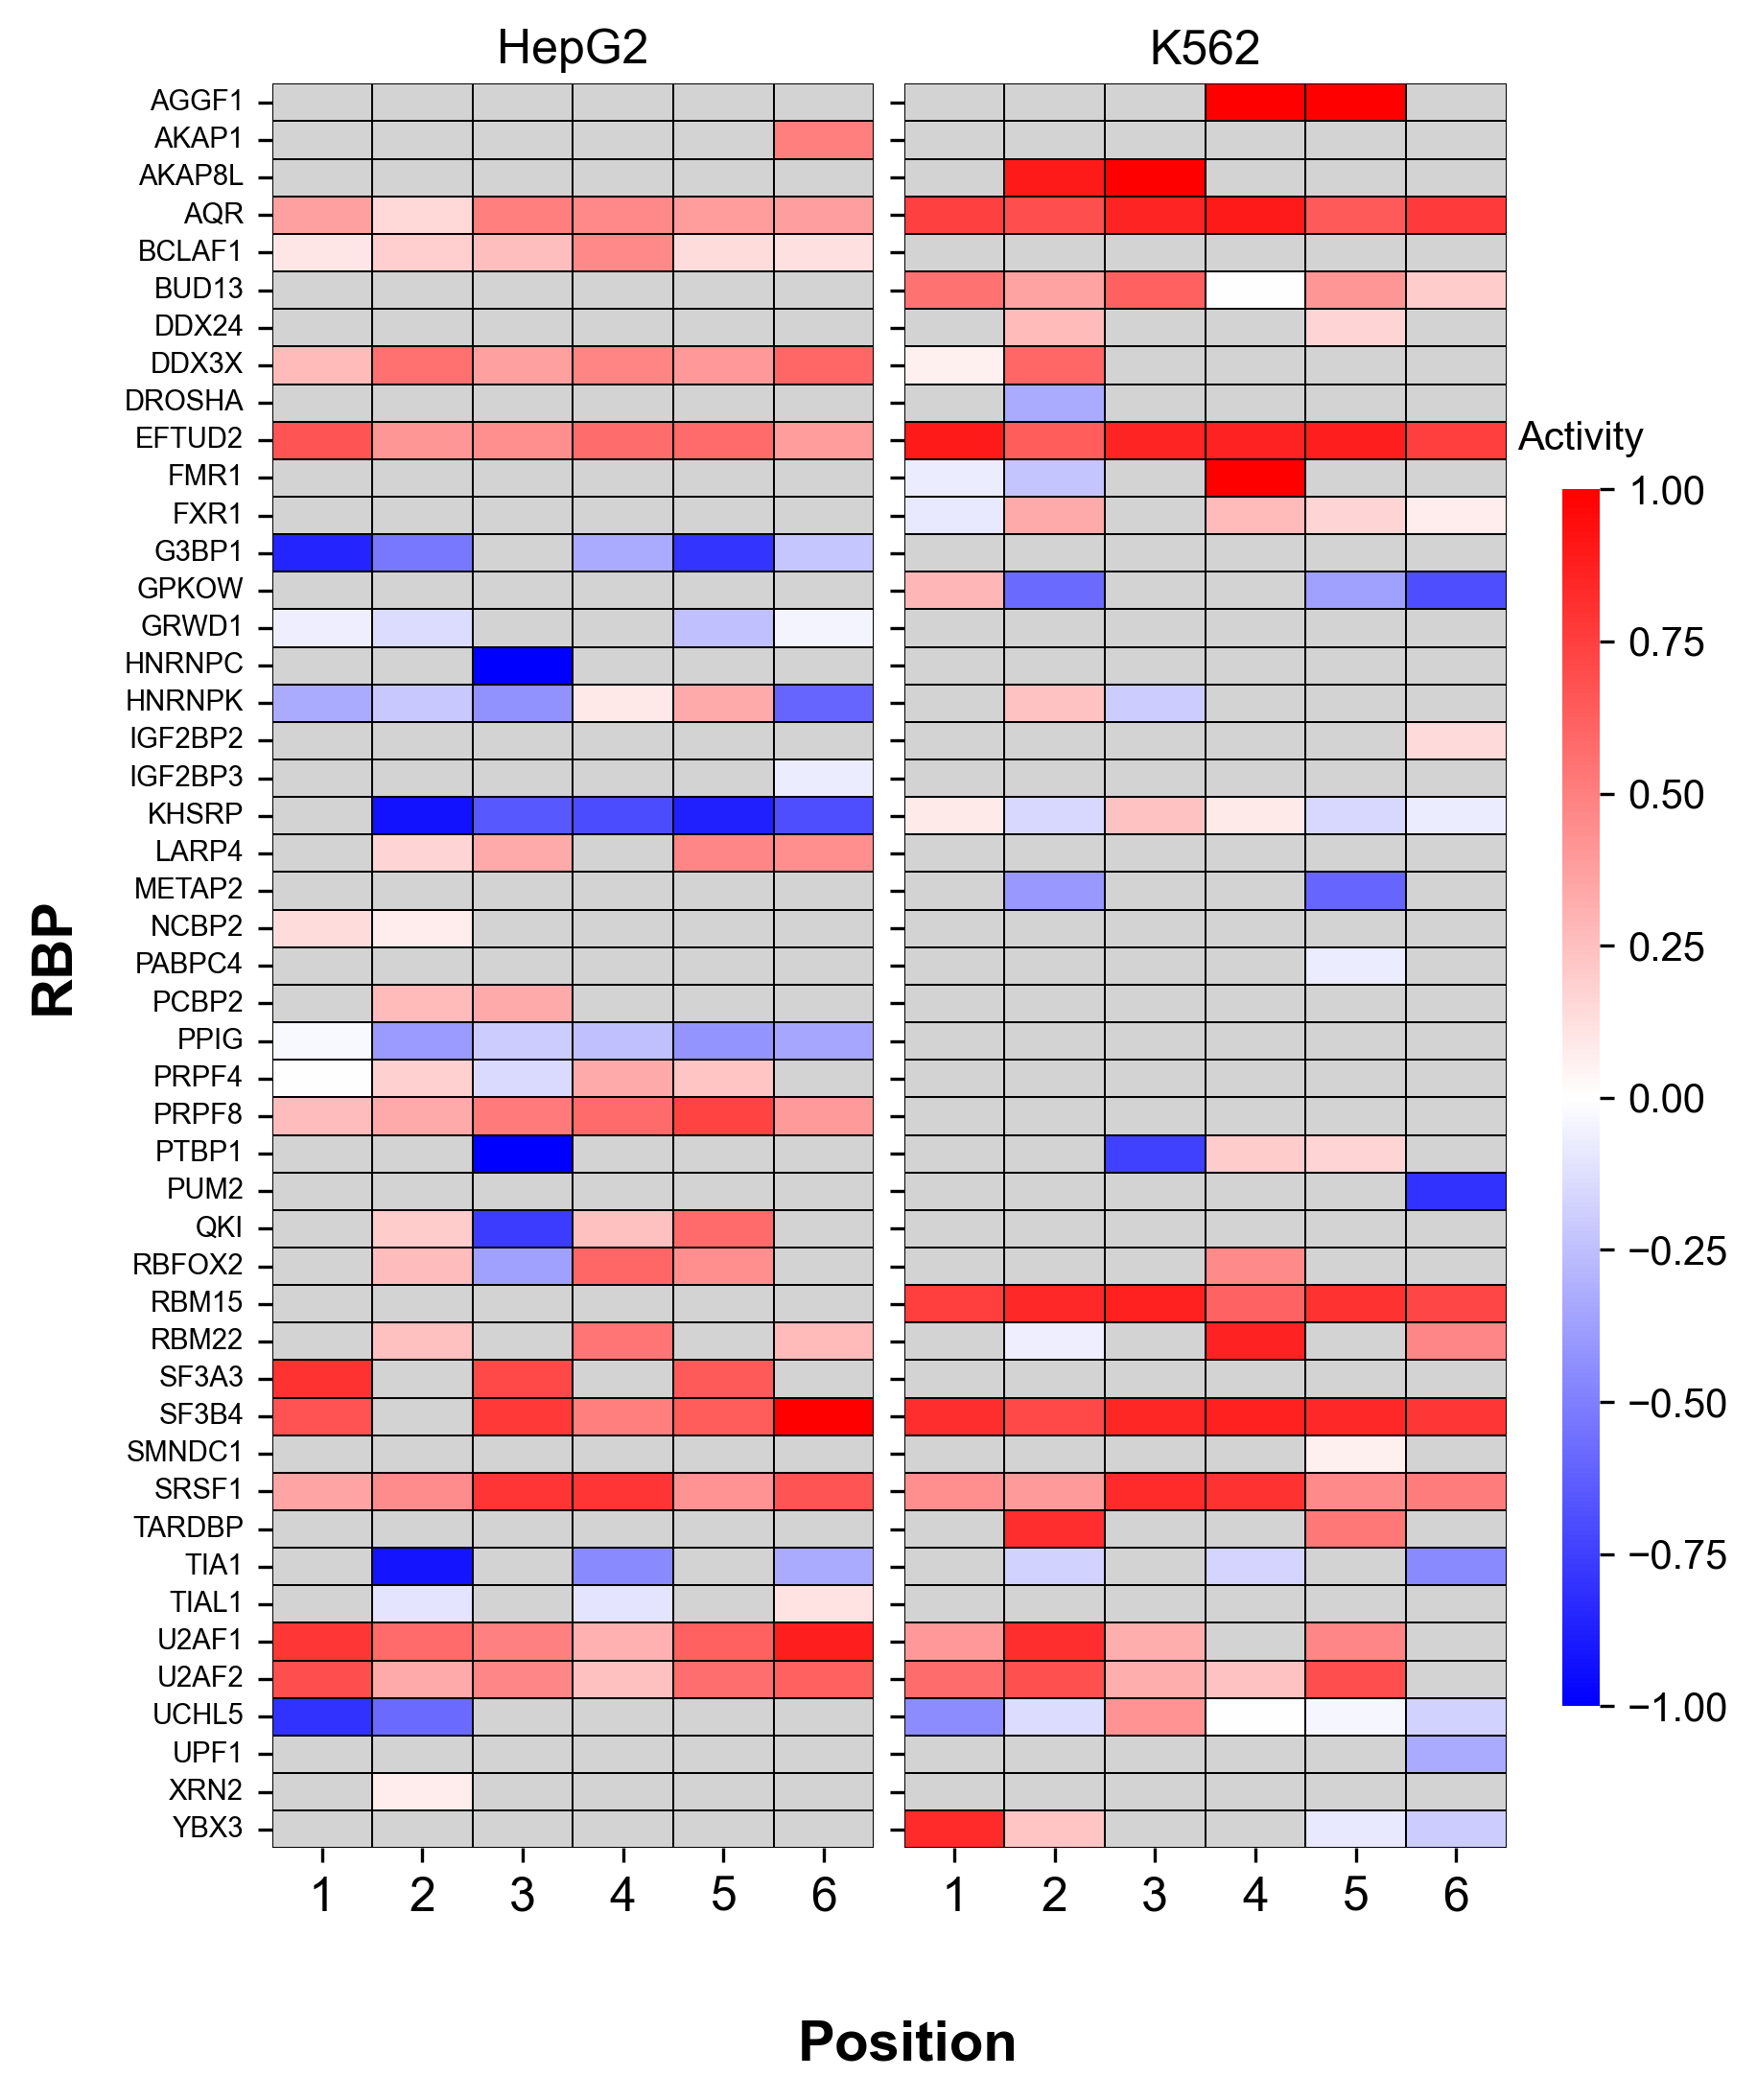

array([<Axes: title={'center': 'HepG2'}>,
       <Axes: title={'center': 'K562'}>], dtype=object)

<Figure size 640x480 with 0 Axes>

In [10]:
plot_rbp_activity_heatmap_test(final_heatmap)

## SHAP vs RBP Activity Score Scatterplot

### This has the new SHAP data (log odds units)

In [15]:
glossary_data_path = f"/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_first_order_SHAP_analysis/outputs/specialized_global_SHAP/signed_local_SHAP_mean_bound_only_unique_binding.pkl"

with open(glossary_data_path, 'rb') as f:
        data = pickle.load(f)

In [16]:
keys = list(data.keys())

HepG2_glossary = pd.DataFrame(data[keys[0]])
K562_glossary = pd.DataFrame(data[keys[1]])

HepG2_glossary.columns.name = None
K562_glossary.columns.name = None

In [12]:
HepG2_glossary.head()

,AGGF1,AKAP1,AQR,BCCIP,BCLAF1,BUD13,CDC40,CSTF2,CSTF2T,DDX3X,...,UCHL5,UPF1,UTP18,WDR43,XPO5,XRCC6,XRN2,YBX3,ZC3H11A,ZNF800
Position,,,,,,,,,,,,,,,,,,,,,
1,0.000000,0.403093,-0.068490,0.0,-0.024510,-0.000355,-0.098853,0.0,0.006724,-0.110271,...,0.004526,0.000000,0.0,0.479473,0.000000,0.0,-0.399362,-0.389574,-0.18869,-0.095414
2,0.000000,0.000000,-0.177027,0.0,-0.112998,-0.002166,0.000000,0.0,0.011539,-0.098131,...,-0.415896,0.000000,0.0,0.000000,0.000000,0.0,-0.284059,-0.013098,0.00000,-0.040900
3,-0.580444,0.000000,0.912755,0.0,1.195804,0.681261,0.000000,0.0,-0.237111,0.998557,...,0.102340,0.000000,0.0,0.000000,-0.160905,0.0,-0.015681,1.033550,0.00000,0.274858
4,0.000000,0.000000,0.586993,0.0,1.249901,0.036882,0.683721,0.0,-0.018564,0.459452,...,0.054905,0.184004,0.0,0.000000,0.000000,0.0,-0.419990,1.396123,0.00000,0.230472
5,0.036039,0.000000,-0.150674,0.0,-0.082798,-0.162271,0.000000,0.0,0.000803,-1.201315,...,-0.023816,0.000623,0.0,0.000000,0.050087,0.0,-0.049692,-0.073768,0.00000,-0.017818


In [13]:
# Ignore zeros

def calculate_sign_concordance_no_zeros(cell_line):
    
    # Manipulate dataframes
    print(cell_line)
    t1 = globals()[f"{cell_line}_heatmap"].copy()
    t2 = globals()[f"{cell_line}_glossary"].T.copy()
    # t2.columns = t2.columns + 1  # shift 0-5 → 1-6 to match t1
    
    t1.index.name = None
    t1.columns.name = None
    t2.index.name = None
    t2.columns.name = None
    
    print("t1 columns:", t1.columns.tolist())
    print("t2 columns:", t2.columns.tolist())
    
    common_proteins = t1.index.intersection(t2.index)
    t1 = t1.loc[common_proteins]
    t2 = t2.loc[common_proteins]
    
    t1, t2 = t1.align(t2, join="inner", axis=1)
    
    print(f"RBPs in common: {len(common_proteins)}")
    print(f"Positions being compared: {t1.shape[1]}")
    
    results = []
    total_match = 0
    total_valid = 0
    
    for protein in common_proteins:
        row1 = t1.loc[protein]
        row2 = t2.loc[protein]
    
        valid = row1.notna() & row2.notna() & (row1 != 0) & (row2 != 0)  # exclude zeros
        r1 = row1[valid]
        r2 = row2[valid]
    
        if len(r1) == 0:
            results.append({"protein": protein, "concordance": np.nan})
            continue
    
        matches = (np.sign(r1.values) == np.sign(r2.values)).sum()
        n        = len(r1)
        pct      = round(matches / n * 100, 2)
    
        total_match += matches
        total_valid += n
    
        results.append({"protein": protein, "concordance": pct})
    
    concordance_df = pd.DataFrame(results)
    total_concordance = round(concordance_df["concordance"].mean(), 2)
    
    print(f"\nTotal sign concordance across all proteins: {total_concordance}%\n")
    print(concordance_df.to_string(index=False))

    print(total_concordance)

    return total_concordance

In [14]:
K562_concordance = calculate_sign_concordance_no_zeros('K562')

K562
t1 columns: [1, 2, 3, 4, 5, 6, 'Cell Line']
t2 columns: [1, 2, 3, 4, 5, 6]
RBPs in common: 31
Positions being compared: 6

Total sign concordance across all proteins: 44.84%

protein  concordance
  AGGF1         0.00
 AKAP8L         0.00
    AQR        33.33
  BUD13        40.00
  DDX24         0.00
  DDX3X         0.00
 DROSHA       100.00
 EFTUD2        66.67
   FMR1        33.33
   FXR1        80.00
  GPKOW       100.00
 HNRNPK        50.00
IGF2BP2         0.00
  KHSRP        83.33
 METAP2       100.00
 PABPC4       100.00
  PTBP1        33.33
   PUM2         0.00
 RBFOX2         0.00
  RBM15        50.00
  RBM22        66.67
  SF3B4        33.33
 SMNDC1         0.00
  SRSF1        50.00
 TARDBP         0.00
   TIA1       100.00
  U2AF1         0.00
  U2AF2        20.00
  UCHL5       100.00
   UPF1       100.00
   YBX3        50.00
44.84


In [15]:
HepG2_concordance = calculate_sign_concordance_no_zeros('HepG2')

HepG2
t1 columns: [1, 2, 3, 4, 5, 6, 'Cell Line']
t2 columns: [1, 2, 3, 4, 5, 6]
RBPs in common: 30
Positions being compared: 6

Total sign concordance across all proteins: 47.0%

protein  concordance
  AKAP1         0.00
    AQR        33.33
 BCLAF1        33.33
  DDX3X        33.33
 EFTUD2        50.00
  G3BP1        60.00
  GRWD1       100.00
 HNRNPC       100.00
 HNRNPK        83.33
IGF2BP3       100.00
  KHSRP       100.00
  LARP4        25.00
  NCBP2         0.00
  PCBP2        50.00
   PPIG        50.00
  PRPF4        50.00
  PRPF8        33.33
  PTBP1       100.00
    QKI        33.33
 RBFOX2        50.00
  RBM22        33.33
  SF3A3        33.33
  SF3B4        25.00
  SRSF1        16.67
   TIA1        66.67
  TIAL1        66.67
  U2AF1        16.67
  U2AF2        16.67
  UCHL5        50.00
   XRN2         0.00
47.0


## Scatterplot RBP Activity vs SHAP with MCC

In [17]:
# Plot Scatterplot with MCC

def scatterplot(cell_line, data):
    
    print(cell_line)
    
    # Filter massive dataframe for KD samples, FDR <= 0.1, abs[DeltaPSI] > 0.

    filtered_data = (
        data
        .filter(
            (data["Sample Name"].str.contains("KD", literal=True))
            & (data["FDR"] <= 0.1)
            & (data["DeltaPSI"].abs() > 0)
        )    
    )

    # Columns 
    columns_to_keep = [
        "RBP_KD_Target",
        "Sample Name",
        "FDR",
        "DeltaPSI",
        "has_RBP_KD_1",
        "has_RBP_KD_2",
        "has_RBP_KD_3",
        "has_RBP_KD_4",
        "has_RBP_KD_5",
        "has_RBP_KD_6",
        "Raw P-Val",
        "rMATS Event ID"
    ]
    
    rbp_targets = (
        filtered_data["RBP_KD_Target"]
        .unique()
        .sort()
        .to_list()
    )
    
    positions = [1,2,3,4,5,6]

    results = []  # collect all results here

    for rbp in rbp_targets:
        for pos in positions:

            rbp_specific_data = (
            filtered_data
            .filter(
                (pl.col("RBP_KD_Target") == rbp) & (pl.col(f"has_RBP_KD_{pos}") == True))
            .unique(subset=["rMATS Event ID"])) # gets in-silico KD rows per RBP per position

            # Drop unneccesary columns
            rbp_specific_data = rbp_specific_data.select(columns_to_keep)

            # Convert to pandas
            df = rbp_specific_data.to_pandas()

            # Prevents error for no data (SAFB or IGF..1)
            data = df["DeltaPSI"]

            if data.empty:
                continue 

            # DPSI conversion
            df["DeltaPSI"] = df["DeltaPSI"] * -1

            # Calculate the number of positive dPSI and the number of negative dPSI

            num_pos = (df["DeltaPSI"] > 0).sum()
            num_neg = (df["DeltaPSI"] < 0).sum()

            # Do not include rows plots with less than 10 sig. points 

            if (num_pos + num_neg) < 10:
                continue 

            # Normalized Difference Score
            norm_diff = (num_pos - num_neg) / (num_pos + num_neg)

            # Append results
            results.append({
                "RBP": rbp,
                "Position": pos,
                "num_pos": num_pos,
                "num_neg": num_neg,
                "norm_diff": norm_diff
            })

    # Final results dataframe
    results_df = pd.DataFrame(results)
    
    df = pd.DataFrame(results_df)

    glossary_data = globals()[f"{cell_line}_glossary"]
    glossary_data = glossary_data.reset_index()
    
    # Melt glossary from wide to long so it matches activity data structure

    glossary_long = glossary_data.melt(id_vars="Position", var_name="RBP", value_name="shap")

    # Merge on position + RBP

    merged = df.merge(glossary_long, on=["RBP", "Position"], how="left")

    print("shap range:")
    print("Max:", merged['shap'].max())
    print("Min:", merged['shap'].min())

    print(merged)

    # Convert to sign-based labels
    merged["pred_sign"] = np.sign(merged["shap"])
    merged["true_sign"] = np.sign(merged["norm_diff"])

    print("with labs")
    print(merged)
    
    # Drop zeros
    merged_mcc = merged[(merged["pred_sign"] != 0) & (merged["true_sign"] != 0)]
    
    mcc = matthews_corrcoef(
        merged_mcc["true_sign"],
        merged_mcc["pred_sign"]
    )

    print(f"MCC (sign-based): {mcc:.4f}")

    
    # Scatterplot
    conditions = [
        (merged["shap"] > 0) & (merged["norm_diff"] > 0),   # Q1
        (merged["shap"] < 0) & (merged["norm_diff"] > 0),   # Q2
        (merged["shap"] < 0) & (merged["norm_diff"] < 0),   # Q3
        (merged["shap"] > 0) & (merged["norm_diff"] < 0),   # Q4
    ]
    colors = ["red", "gray", "blue", "gray"]
    merged["quadrant_color"] = np.select(conditions, colors, default="black")
    
    # Count quadrant points
    q1 = ((merged["shap"] > 0) & (merged["norm_diff"] > 0)).sum()
    q3 = ((merged["shap"] < 0) & (merged["norm_diff"] < 0)).sum()
    
    total_points = len(merged)
    
    
    conc = ((q1 + q3) / total_points) if q3 != 0 else np.nan
    conc = conc * 100
    
    label = r'Avg. SHAP'
    score = r'Activity'
    plt.style.use("/project/PlatigLab/users/reece/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/07_reece_biological_validations/paper.mplstyle")
    plt.figure(figsize=(8, 6))
    plt.scatter(merged["shap"], merged["norm_diff"], c=merged["quadrant_color"], alpha=0.5)

    plt.xlim(-1.5, 1.3)
    plt.ylim(-1.05, 1.05)
    
    # Add horizontal & vertical lines at 0 to create 4 quadrants
    plt.axhline(0, color="black", linestyle="--", linewidth=1)
    plt.axvline(0, color="black", linestyle="--", linewidth=1)
    
    # Labels & title
    plt.xlabel(label, fontsize=21, labelpad=15)
    plt.ylabel(score, fontsize=21, labelpad=15)
    ax = plt.gca()
    ax.text(0.02, 0.97, f"{cell_line}", transform=ax.transAxes,
            fontsize=22, fontweight='bold', va='top', ha='left')
    
    ax.text(
        0.98, 0.03,
        f"MCC = {mcc:.2f}\n"
        f"Sign Concordance: {conc:.1f}%",
        transform=ax.transAxes,
        fontsize=15,
        va='bottom',
        ha='right',
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="none",
            edgecolor="lightgray",
            alpha=0.6
        )
    )

    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.show()



K562
shap range:
Max: 1.2414154757758578
Min: -0.4014310154366737
        RBP  Position  num_pos  num_neg  norm_diff      shap
0     AGGF1         4       11        0   1.000000 -0.114320
1     AGGF1         5       16        0   1.000000 -0.009366
2    AKAP8L         2       18        1   0.894737 -0.000870
3    AKAP8L         3       10        0   1.000000 -0.009253
4       AQR         1      365       54   0.742243 -0.016039
..      ...       ...      ...      ...        ...       ...
98     UPF1         6        6       12  -0.333333 -0.024331
99     YBX3         1       11        1   0.833333 -0.002301
100    YBX3         2        8        5   0.230769 -0.104694
101    YBX3         5        5        6  -0.090909 -0.019036
102    YBX3         6        4        6  -0.200000 -0.220334

[103 rows x 6 columns]
with labs
        RBP  Position  num_pos  num_neg  norm_diff      shap  pred_sign  \
0     AGGF1         4       11        0   1.000000 -0.114320       -1.0   
1     AGGF1       

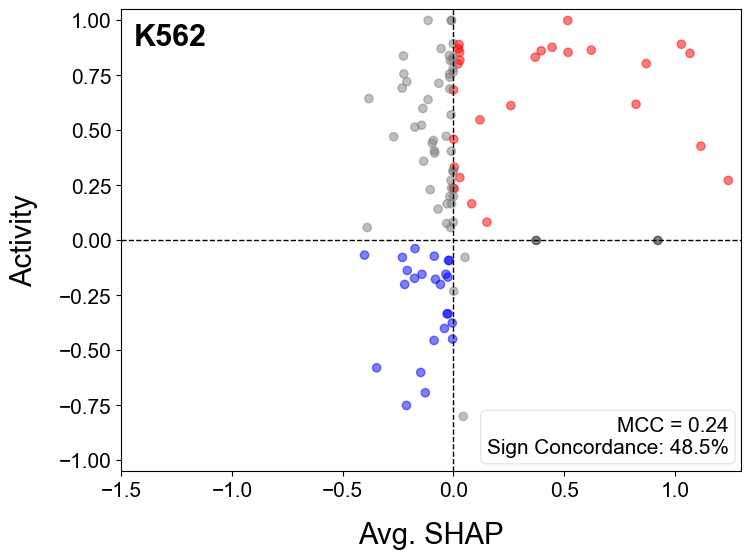

In [18]:
scatterplot('K562', all_model_data_K562)

HepG2
shap range:
Max: 1.372571260118601
Min: -1.4731048998171397
       RBP  Position  num_pos  num_neg  norm_diff      shap
0    AKAP1         6        9        3   0.500000 -0.044942
1      AQR         1       57       26   0.373494 -0.068490
2      AQR         2       56       41   0.154639 -0.177027
3      AQR         3       58       19   0.506494  0.912755
4      AQR         4       41       15   0.464286  0.586993
..     ...       ...      ...      ...        ...       ...
114  U2AF2         5      409      113   0.567050 -0.156785
115  U2AF2         6       47       11   0.620690 -0.048858
116  UCHL5         1        1        9  -0.800000  0.004526
117  UCHL5         2        4       15  -0.578947 -0.415896
118   XRN2         2        7        6   0.076923 -0.284059

[119 rows x 6 columns]
with labs
       RBP  Position  num_pos  num_neg  norm_diff      shap  pred_sign  \
0    AKAP1         6        9        3   0.500000 -0.044942       -1.0   
1      AQR         1       57   

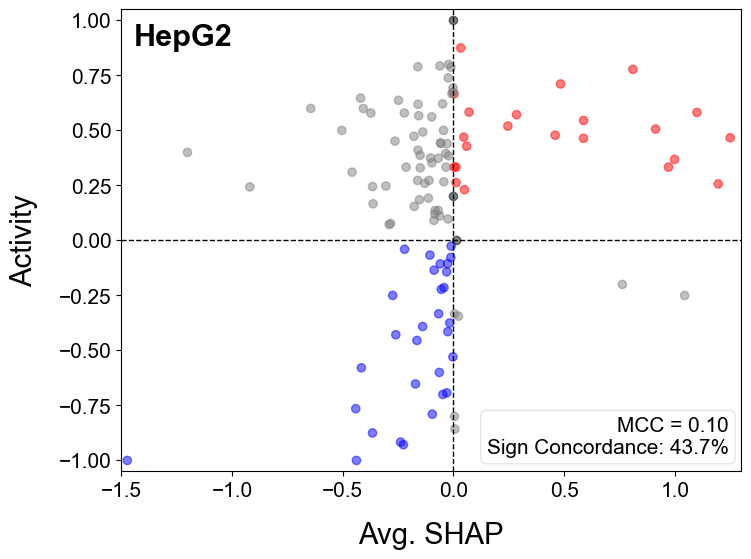

In [19]:
scatterplot('HepG2', all_model_data_HepG2)